# Analyse des Données Météorologiques NOAA - UrbanHub (Rôle 1)

Ce notebook présente l'analyse descriptive et exploratoire des données météorologiques historiques horaires de la NOAA agrégées en Gold.
Il couvre 4 questions clés :
- **Q1** : Détection des périodes météorologiques anormales
- **Q2** : Corrélation entre les variables météo et la visibilité
- **Q3** : Évolution saisonnière de la température en France
- **Q4** : Détection des jours météorologiques extrêmes

## 1. Configuration et connexion MinIO

In [1]:
import sys
import os
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO
from minio import Minio
from dotenv import load_dotenv

load_dotenv('../.env')

client = Minio(
    os.getenv('MINIO_ENDPOINT', 'localhost:9000'),
    access_key=os.getenv('MINIO_ROOT_USER', 'minioadmin'),
    secret_key=os.getenv('MINIO_ROOT_PASSWORD', 'minioadmin123'),
    secure=False
)

BUCKET_GOLD = os.getenv('BUCKET_GOLD', 'urbanhub-gold')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
%matplotlib inline
print('Configuration OK')

Configuration OK


## 2. Chargement des données Gold depuis MinIO

In [2]:
def load_gold(filename):
    """Charge un fichier Parquet depuis le bucket Gold MinIO."""
    path = f'meteo/gold/{filename}'
    response = client.get_object(BUCKET_GOLD, path)
    return pq.read_table(BytesIO(response.read())).to_pandas()

df_anomalies = load_gold('anomalies_temperature.parquet')
df_corr      = load_gold('correlation_meteo_visibilite.parquet')
df_seasonal  = load_gold('evolution_saisonniere.parquet')
df_extremes  = load_gold('jours_extremes.parquet')

print('Anomalies      :', df_anomalies.shape)
print('Correlations   :', df_corr.shape)
print('Saisonnalite   :', df_seasonal.shape)
print('Jours extremes :', df_extremes.shape)

Anomalies      : (56, 6)
Correlations   : (4, 5)
Saisonnalite   : (19, 6)
Jours extremes : (1682, 12)


## Q1 — Périodes météorologiques anormales

In [3]:
print(df_anomalies.head(10))
print(f'\n{len(df_anomalies)} periodes anormales detectees')

   year  month  nb_anomalies  temp_min  temp_max   temp_moy
0  2021      1          4168     -12.1      23.0   1.080734
1  2021      2         10996     -16.0      23.0   5.040360
2  2021      3         12423      -7.6      28.3  10.686034
3  2021      4         13366      -9.5      28.0   5.561387
4  2021      5         11323      -3.6      33.0   7.086885
5  2021      6          6269       0.0      37.0  18.272803
6  2021      7          4044       0.0      39.6  15.913699
7  2021      8          4593       0.0      40.0  17.295558
8  2021      9          6972       0.0      37.0  17.813210
9  2021     10         15778      -4.0      30.0   4.847769

56 periodes anormales detectees


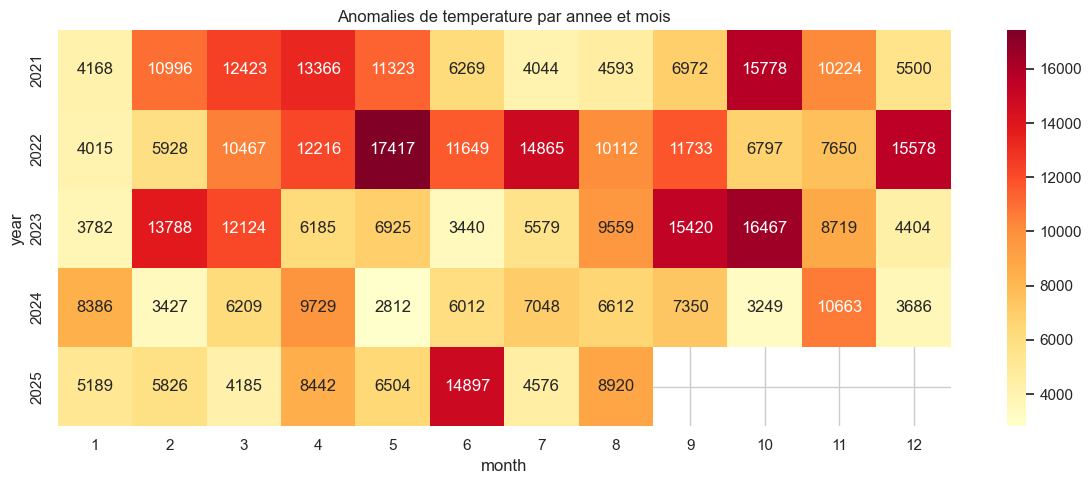

In [4]:
# Heatmap des anomalies par année et mois
pivot = df_anomalies.pivot_table(index='year', columns='month', values='nb_anomalies', aggfunc='sum')
plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Anomalies de temperature par annee et mois')
plt.tight_layout()
plt.show()

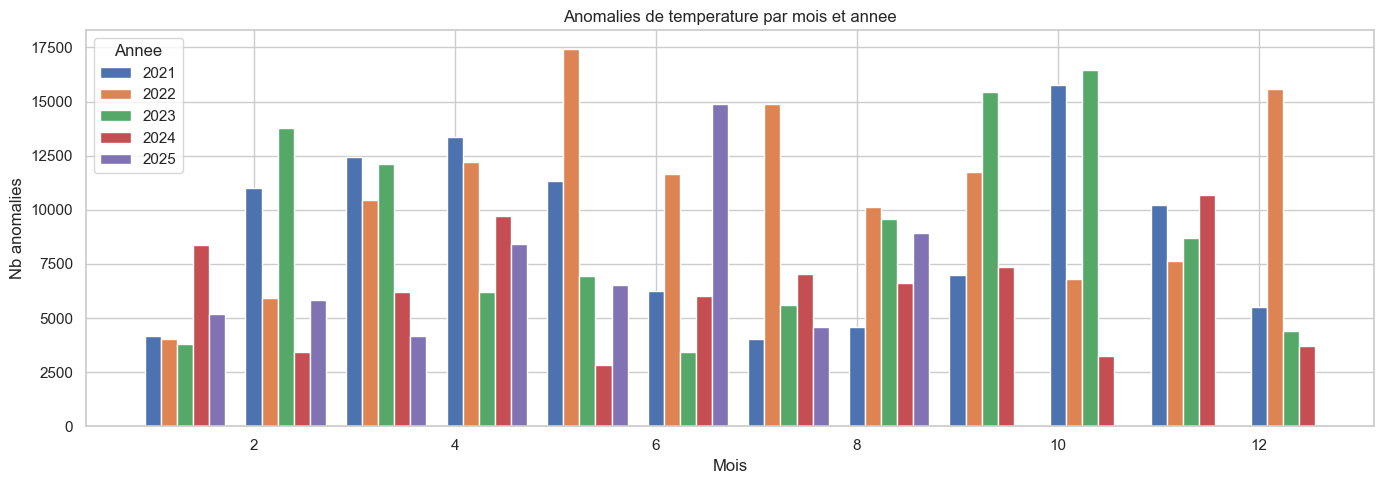

In [5]:
# Barplot groupé par mois et année
df_anom_grouped = df_anomalies.groupby(['month', 'year'])['nb_anomalies'].sum().reset_index()
years = sorted(df_anom_grouped['year'].unique())

plt.figure(figsize=(14, 5))
width = 0.8 / len(years)
for i, year in enumerate(years):
    subset = df_anom_grouped[df_anom_grouped['year'] == year]
    plt.bar(subset['month'] + i * width, subset['nb_anomalies'], width=width, label=str(year))

plt.title('Anomalies de temperature par mois et annee')
plt.xlabel('Mois')
plt.ylabel('Nb anomalies')
plt.legend(title='Annee')
plt.tight_layout()
plt.show()

## Q2 — Corrélation entre les variables météo et la visibilité

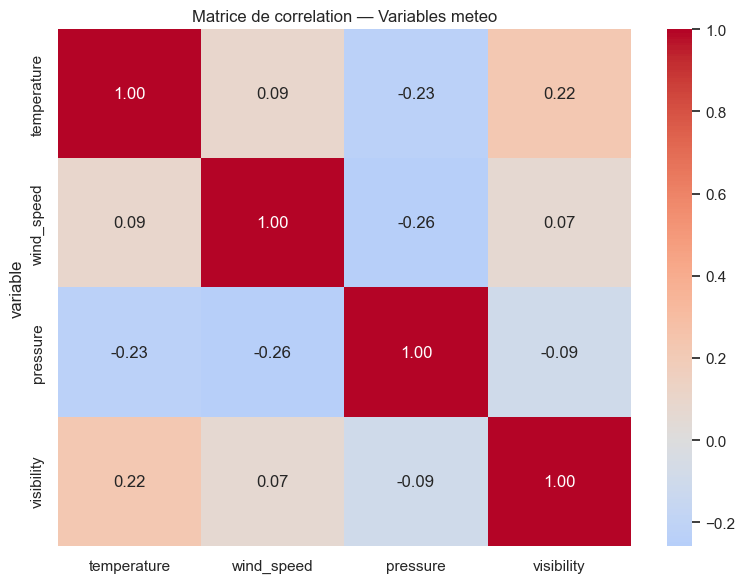

In [6]:
df_corr_matrix = df_corr.set_index('variable').astype(float)

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matrice de correlation — Variables meteo')
plt.tight_layout()
plt.show()

## Q3 — Évolution saisonnière de la température

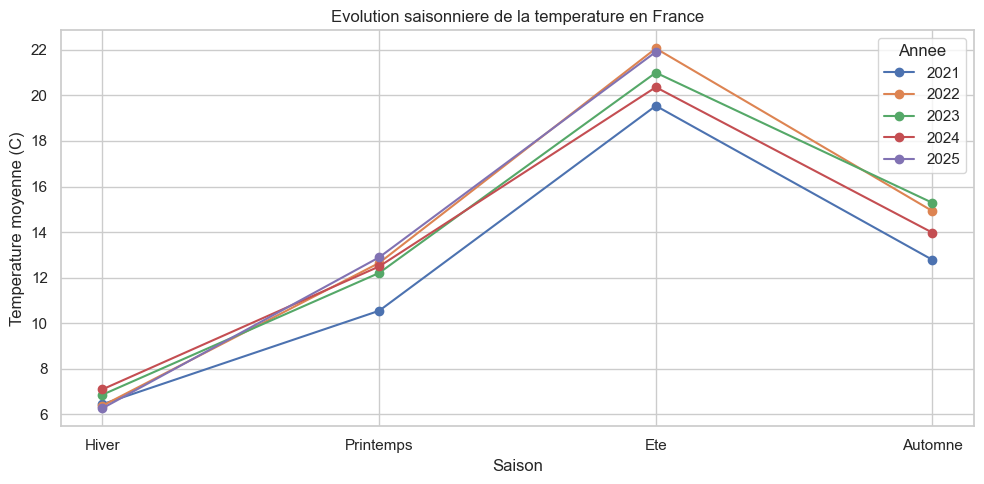

In [7]:
saison_order = ['Hiver', 'Printemps', 'Ete', 'Automne']

# Remplacer "Été" par "Ete" si besoin pour éviter les problèmes d'encodage
df_seasonal['saison'] = df_seasonal['saison'].str.replace('É', 'E').str.replace('é', 'e')
saison_order_norm = ['Hiver', 'Printemps', 'Ete', 'Automne']

df_seasonal['saison'] = pd.Categorical(df_seasonal['saison'], categories=saison_order_norm, ordered=True)
df_seasonal_sorted = df_seasonal.sort_values(['year', 'saison'])

plt.figure(figsize=(10, 5))
for year in sorted(df_seasonal_sorted['year'].unique()):
    subset = df_seasonal_sorted[df_seasonal_sorted['year'] == year]
    plt.plot(subset['saison'].astype(str), subset['temp_moyenne'], marker='o', label=str(year))

plt.title('Evolution saisonniere de la temperature en France')
plt.xlabel('Saison')
plt.ylabel('Temperature moyenne (C)')
plt.legend(title='Annee')
plt.tight_layout()
plt.show()

## Q4 — Détection et analyse des jours extrêmes

Repartition des jours extremes :
  gel             : 692 jours
  canicule        : 234 jours
  tempete         : 614 jours
  fortes_pluies   : 1245 jours
  brouillard      : 1654 jours


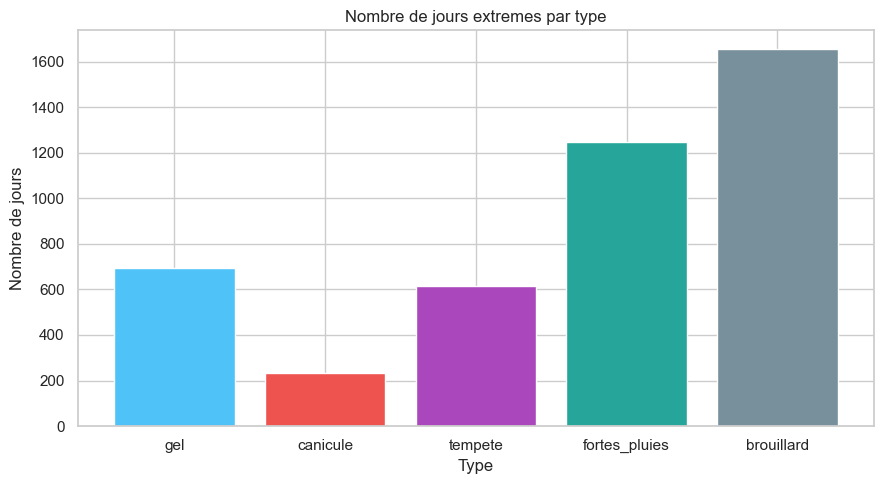

In [8]:
types = ['gel', 'canicule', 'tempete', 'fortes_pluies', 'brouillard']
counts = {t: int(df_extremes[t].sum()) for t in types}

print('Repartition des jours extremes :')
for k, v in counts.items():
    print(f'  {k:<15} : {v} jours')

plt.figure(figsize=(9, 5))
plt.bar(counts.keys(), counts.values(),
        color=['#4fc3f7', '#ef5350', '#ab47bc', '#26a69a', '#78909c'])
plt.title('Nombre de jours extremes par type')
plt.xlabel('Type')
plt.ylabel('Nombre de jours')
plt.tight_layout()
plt.show()

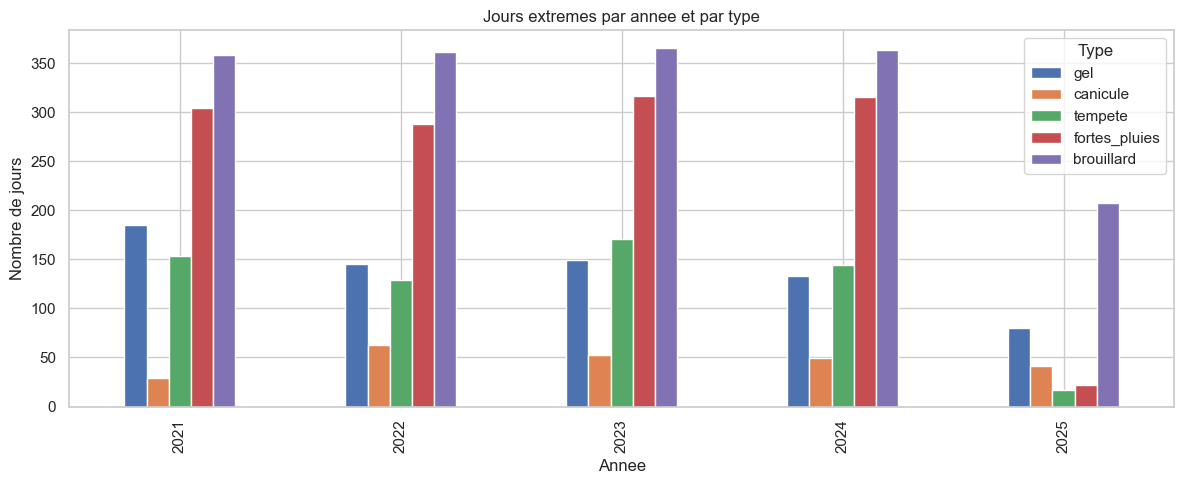

In [9]:
# Évolution des jours extrêmes par année
df_extremes['date'] = pd.to_datetime(df_extremes['date'])
df_extremes['year'] = df_extremes['date'].dt.year

yearly = df_extremes.groupby('year')[types].sum().reset_index()

yearly.set_index('year')[types].plot(kind='bar', figsize=(12, 5))
plt.title('Jours extremes par annee et par type')
plt.xlabel('Annee')
plt.ylabel('Nombre de jours')
plt.legend(title='Type')
plt.tight_layout()
plt.show()